<a href="https://colab.research.google.com/github/hasana1atwit/Simulating-Brownian-Motion-and-Stochastic-Processes/blob/main/Brownian_Motion_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

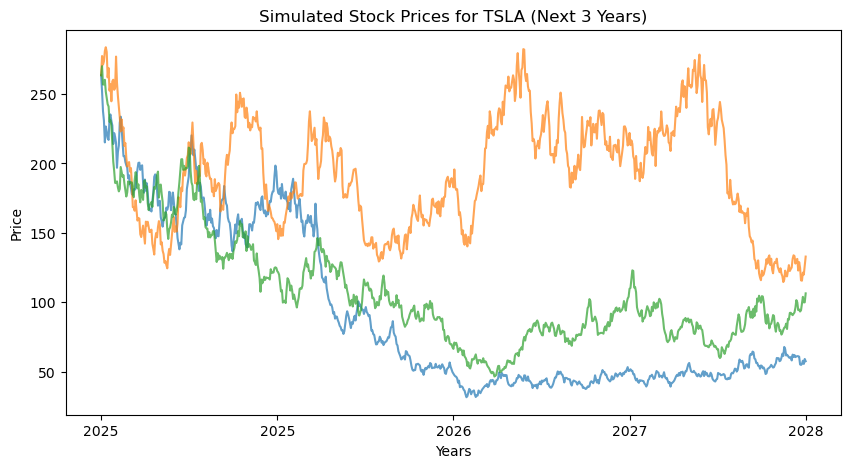

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

def get_stock_data(ticker, period="3y"):
    """Fetch historical stock data from Yahoo Finance."""
    stock = yf.Ticker(ticker)
    df = stock.history(period=period)
    return df["Close"]

def calculate_parameters(stock_prices):
    """Calculate annualized return and volatility."""
    log_returns = np.log(stock_prices / stock_prices.shift(1)).dropna()
    mu = log_returns.mean() * 252  # Annualized return (252 b/c there are 252 trading days in the year).
    sigma = log_returns.std() * np.sqrt(252)  # Annualized volatility
    return mu, sigma

"""S0 is the inital stock price (today),
mu is the expected return
sigma is the volatility (how much the stock price fluctuates (from histroical data)
T is the total time of the simulation
N is the time steps in the simulation (trading days)
M is the number of simulated paths
"""
def brownian_motion(S0, mu, sigma, T, N, M):
    dt = T / N # Step size
    S = np.zeros((N+1, M)) # Creates a matrix, s, initally filled with zeros, where rows represent time steps and columns represent patjs
    S[0] = S0 # First row is set to the inital stock price (today)

    for t in range(1, N+1):
        dW = np.random.normal(0, np.sqrt(dt), M) # Generates random samples from a normal distribution
        S[t] = S[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * dW) # Updates the stock price at time t using Geometric Brownian Motion formula

    return S

# 1️⃣ Choose a Stock (e.g., Tesla)
ticker = "TSLA"  # Change this to any stock symbol
stock_prices = get_stock_data(ticker)
S0 = stock_prices.iloc[-1]  # Last available stock price
mu, sigma = calculate_parameters(stock_prices)

# 2️⃣ Simulation Parameters for 3 Years
T = 3         # Predict next 3 years
N = 252 * T   # Total trading days (252 per year)
M = 3       # Number of simulated paths

# 3️⃣ Simulate and Plot
bm_paths = brownian_motion(S0, mu, sigma, T, N, M)

# X-axis adjustments
years = np.linspace(0, T, num=5)  # Create year markers
x_ticks = np.linspace(0, N, num=5)  # Match trading days to years

plt.figure(figsize=(10,5))
plt.plot(bm_paths, alpha=0.7)
plt.title(f"Simulated Stock Prices for {ticker} (Next 3 Years)")
plt.xlabel("Years")
plt.ylabel("Price")
plt.xticks(x_ticks, labels=[f"{int(2025 + i)}" for i in years])  # Adjust to show actual years

plt.show()